# Sistema de Recuperación de Información con Embeddings

**Materia:** ICCD753 Recuperación de Información 2026-A  
**Examen:** Primer Bimestre
**Nombre:** Jorge Bósquez  
**Dataset:** Rotten Tomatoes Movies and Critic Reviews Dataset

Este notebook implementa un sistema de recuperación de información que:
- carga el corpus,
- selecciona campos textuales,
- preprocesa texto,
- genera embeddings,
- recupera documentos con similitud coseno,
- ejecuta las 8 consultas obligatorias,
- muestra tablas Top-k,
- genera una tabla resumen general,
- incluye una mejora: visualización PCA de embeddings.


## 1. Instalación de librerías

Ejecuta esta celda si estás trabajando en Google Colab o si no tienes instaladas las dependencias.


In [52]:
pip install pandas numpy scikit-learn sentence-transformers matplotlib seaborn nltk

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: pandas in c:\users\jotab\appdata\local\programs\python\python310\lib\site-packages (2.2.3)




[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Importación de librerías

In [53]:
import os
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

pd.set_option("display.max_colwidth", 160)

## 3. Carga del corpus

Coloca los archivos CSV del dataset en una carpeta llamada `data`.

Archivos esperados:
- `data/rotten_tomatoes_movies.csv`
- `data/rotten_tomatoes_critic_reviews.csv`

Para este sistema se usará principalmente el archivo de reseñas, porque contiene texto crítico útil para la recuperación semántica.


In [54]:
import os
import pandas as pd

DATA_DIR = "archive"

movies_path = os.path.join(DATA_DIR, "rotten_tomatoes_movies.csv")
reviews_path = os.path.join(DATA_DIR, "rotten_tomatoes_critic_reviews.csv")

# verificar existencia
if not os.path.exists(movies_path):
    raise FileNotFoundError(
        "No se encontró rotten_tomatoes_movies.csv"
    )

if not os.path.exists(reviews_path):
    raise FileNotFoundError(
        "No se encontró rotten_tomatoes_critic_reviews.csv"
    )

# cargar datasets
movies_df = pd.read_csv(movies_path)
reviews_df = pd.read_csv(reviews_path)

# MERGE
corpus_df = reviews_df.merge(
    movies_df,
    on="rotten_tomatoes_link",
    how="left"
)

# doc_id
corpus_df["doc_id"] = range(len(corpus_df))

print("Dimensiones del corpus:", corpus_df.shape)

corpus_df.head()

Dimensiones del corpus: (1130017, 30)


,rotten_tomatoes_link,critic_name,top_critic,publisher_name,review_type,review_score,review_date,review_content,movie_title,movie_info,...,tomatometer_status,tomatometer_rating,tomatometer_count,audience_status,audience_rating,audience_count,tomatometer_top_critics_count,tomatometer_fresh_critics_count,tomatometer_rotten_critics_count,doc_id
0,m/0814255,Andrew L. Urban,False,Urban Cinefile,Fresh,NaN,2010-02-06,A fantasy adventure that fuses Greek mythology to contemporary American places and values. Anyone around 15 (give or take a couple of years) will thrill to ...,Percy Jackson & the Olympians: The Lightning Thief,"Always trouble-prone, the life of teenager Percy Jackson (Logan Lerman) gets a lot more complicated when he learns he's the son of the Greek god Poseidon. A...",...,Rotten,49.0,149.0,Spilled,53.0,254421.0,43.0,73.0,76.0,0
1,m/0814255,Louise Keller,False,Urban Cinefile,Fresh,NaN,2010-02-06,"Uma Thurman as Medusa, the gorgon with a coiffure of writhing snakes and stone-inducing hypnotic gaze is one of the highlights of this bewitching fantasy",Percy Jackson & the Olympians: The Lightning Thief,"Always trouble-prone, the life of teenager Percy Jackson (Logan Lerman) gets a lot more complicated when he learns he's the son of the Greek god Poseidon. A...",...,Rotten,49.0,149.0,Spilled,53.0,254421.0,43.0,73.0,76.0,1
2,m/0814255,NaN,False,FILMINK (Australia),Fresh,NaN,2010-02-09,"With a top-notch cast and dazzling special effects, this will tide the teens over until the next Harry Potter instalment.",Percy Jackson & the Olympians: The Lightning Thief,"Always trouble-prone, the life of teenager Percy Jackson (Logan Lerman) gets a lot more complicated when he learns he's the son of the Greek god Poseidon. A...",...,Rotten,49.0,149.0,Spilled,53.0,254421.0,43.0,73.0,76.0,2
3,m/0814255,Ben McEachen,False,Sunday Mail (Australia),Fresh,3.5/5,2010-02-09,"Whether audiences will get behind The Lightning Thief is hard to predict. Overall, it's an entertaining introduction to a promising new world -- but will th...",Percy Jackson & the Olympians: The Lightning Thief,"Always trouble-prone, the life of teenager Percy Jackson (Logan Lerman) gets a lot more complicated when he learns he's the son of the Greek god Poseidon. A...",...,Rotten,49.0,149.0,Spilled,53.0,254421.0,43.0,73.0,76.0,3
4,m/0814255,Ethan Alter,True,Hollywood Reporter,Rotten,NaN,2010-02-10,"What's really lacking in The Lightning Thief is a genuine sense of wonder, the same thing that brings viewers back to Hogwarts over and over again.",Percy Jackson & the Olympians: The Lightning Thief,"Always trouble-prone, the life of teenager Percy Jackson (Logan Lerman) gets a lot more complicated when he learns he's the son of the Greek god Poseidon. A...",...,Rotten,49.0,149.0,Spilled,53.0,254421.0,43.0,73.0,76.0,4


## 4. Exploración de columnas

In [55]:
print("Columnas disponibles:")
print(corpus_df.columns.tolist())

Columnas disponibles:
['rotten_tomatoes_link', 'critic_name', 'top_critic', 'publisher_name', 'review_type', 'review_score', 'review_date', 'review_content', 'movie_title', 'movie_info', 'critics_consensus', 'content_rating', 'genres', 'directors', 'authors', 'actors', 'original_release_date', 'streaming_release_date', 'runtime', 'production_company', 'tomatometer_status', 'tomatometer_rating', 'tomatometer_count', 'audience_status', 'audience_rating', 'audience_count', 'tomatometer_top_critics_count', 'tomatometer_fresh_critics_count', 'tomatometer_rotten_critics_count', 'doc_id']


## 5. Selección de campos textuales

Se construirá un documento por cada reseña usando:
- título de la película,
- contenido de la crítica,
- nombre del crítico,
- editorial o medio, si existe.

El campo más importante es el contenido de la crítica.


In [56]:
# Ajuste flexible por si el CSV tiene nombres de columnas ligeramente distintos.
possible_title_cols = ["movie_title", "title", "movie"]
possible_review_cols = ["review_content", "review", "content", "critic_review"]
possible_critic_cols = ["critic_name", "critic", "author"]
possible_publisher_cols = ["publisher_name", "publisher", "publication"]

def find_col(df, possible_cols):
    for col in possible_cols:
        if col in df.columns:
            return col
    return None

title_col = find_col(corpus_df, possible_title_cols)
review_col = find_col(corpus_df, possible_review_cols)
critic_col = find_col(corpus_df, possible_critic_cols)
publisher_col = find_col(corpus_df, possible_publisher_cols)

print("Columna título:", title_col)
print("Columna reseña:", review_col)
print("Columna crítico:", critic_col)
print("Columna medio:", publisher_col)

if review_col is None:
    raise ValueError("No se encontró una columna de reseña. Revisa los nombres de columnas del CSV.")

# Selección de columnas necesarias desde corpus_df, NO desde reviews_df
selected_cols = [c for c in [title_col, review_col, critic_col, publisher_col, "rotten_tomatoes_link"] if c is not None]

corpus_df = corpus_df[selected_cols].copy()

# Eliminar reseñas vacías
corpus_df = corpus_df.dropna(subset=[review_col])
corpus_df = corpus_df[corpus_df[review_col].astype(str).str.strip() != ""]

# Para evitar tiempos muy largos, puedes limitar el corpus.
MAX_DOCS = 20000

if MAX_DOCS is not None and len(corpus_df) > MAX_DOCS:
    corpus_df = corpus_df.sample(MAX_DOCS, random_state=42).reset_index(drop=True)
else:
    corpus_df = corpus_df.reset_index(drop=True)

corpus_df["doc_id"] = corpus_df.index.astype(str)

print("Documentos usados:", len(corpus_df))
corpus_df.head()

Columna título: movie_title
Columna reseña: review_content
Columna crítico: critic_name
Columna medio: publisher_name


Documentos usados: 20000


,movie_title,review_content,critic_name,publisher_name,rotten_tomatoes_link,doc_id
0,Snatched,"It's predictable stuff for the most part, and the jokes thin out half way through, but Schumer and Hawn are great together, and Schumer wrings every last dr...",Paul Whitington,Irish Independent,m/snatched_2017,0
1,Eden,"Though the film defines Paul's life by his relationships, Eden fails to muster the kind of emotional intensity its story dictates.",Tina Hassannia,Movie Mezzanine,m/eden_2015,1
2,Cold Fish,"Just as with Suicide Club, the deliberate weirdness and detached tone of Cold Fish may initially leave audiences befuddled, but this a sign of its complexity.",Virginie Sélavy,Electric Sheep,m/cold_fish,2
3,Bad Boys,"""Bad Boys"" misses its chance at greatness, but it's saying something that this movie had a chance. I have a notion it will stand as one of those bench-mark ...",Roger Ebert,Chicago Sun-Times,m/bad_boys_1982,3
4,Amulet,"Creepy, bloody, and flat-out weird in places, Amulet is a bold directorial debut for Garai and a disquieting reminder that getting rid of the past is never ...",Alissa Wilkinson,Vox,m/amulet,4


## 6. Preprocesamiento

Pipeline obligatorio:
- conversión a minúsculas,
- eliminación de signos de puntuación,
- eliminación de espacios redundantes.

También se normaliza texto vacío para evitar errores.


In [57]:
import re
import string

def preprocess_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text)
    text = text.strip()

    return text

def build_document(row):

    parts = []

    # título película
    if title_col is not None:
        parts.append(f"Movie title: {row[title_col]}")

    # review
    parts.append(f"Review: {row[review_col]}")

    # critic
    if critic_col is not None:
        parts.append(f"Critic: {row[critic_col]}")

    # publisher
    if publisher_col is not None:
        parts.append(f"Publisher: {row[publisher_col]}")

    return " ".join([str(p) for p in parts if pd.notna(p)])

# construir documentos
corpus_df["raw_text"] = corpus_df.apply(build_document, axis=1)

# preprocesamiento
corpus_df["processed_text"] = corpus_df["raw_text"].apply(preprocess_text)

# visualizar
corpus_df[[
    "doc_id",
    title_col,
    "processed_text",
    review_col
]].head()

,doc_id,movie_title,processed_text,review_content
0,0,Snatched,movie title snatched review its predictable stuff for the most part and the jokes thin out half way through but schumer and hawn are great together and schu...,"It's predictable stuff for the most part, and the jokes thin out half way through, but Schumer and Hawn are great together, and Schumer wrings every last dr..."
1,1,Eden,movie title eden review though the film defines pauls life by his relationships eden fails to muster the kind of emotional intensity its story dictates crit...,"Though the film defines Paul's life by his relationships, Eden fails to muster the kind of emotional intensity its story dictates."
2,2,Cold Fish,movie title cold fish review just as with suicide club the deliberate weirdness and detached tone of cold fish may initially leave audiences befuddled but t...,"Just as with Suicide Club, the deliberate weirdness and detached tone of Cold Fish may initially leave audiences befuddled, but this a sign of its complexity."
3,3,Bad Boys,movie title bad boys review bad boys misses its chance at greatness but its saying something that this movie had a chance i have a notion it will stand as o...,"""Bad Boys"" misses its chance at greatness, but it's saying something that this movie had a chance. I have a notion it will stand as one of those bench-mark ..."
4,4,Amulet,movie title amulet review creepy bloody and flatout weird in places amulet is a bold directorial debut for garai and a disquieting reminder that getting rid...,"Creepy, bloody, and flat-out weird in places, Amulet is a bold directorial debut for Garai and a disquieting reminder that getting rid of the past is never ..."


## 7. Generación de embeddings

Se utiliza el modelo `all-MiniLM-L6-v2` de Sentence Transformers, porque es liviano, rápido y adecuado para similitud semántica.

Se guardan los embeddings en caché para evitar recalcularlos cada vez.


In [58]:
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
EMBEDDINGS_CACHE = "embeddings_rotten_tomatoes.npy"

model = SentenceTransformer(MODEL_NAME)

documents = corpus_df["processed_text"].tolist()

if os.path.exists(EMBEDDINGS_CACHE):
    doc_embeddings = np.load(EMBEDDINGS_CACHE)
    print("Embeddings cargados desde caché:", doc_embeddings.shape)
else:
    doc_embeddings = model.encode(
        documents,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    np.save(EMBEDDINGS_CACHE, doc_embeddings)
    print("Embeddings generados y guardados:", doc_embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Embeddings generados y guardados: (20000, 384)


## 8. Función de recuperación con similitud coseno

Para cada consulta:
1. se preprocesa el texto,
2. se genera su embedding,
3. se calcula similitud coseno contra todos los documentos,
4. se devuelven los Top-k documentos ordenados.


In [59]:
def search_documents(query, top_k=10):
    processed_query = preprocess_text(query)

    query_embedding = model.encode(
        [processed_query],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    similarities = cosine_similarity(query_embedding, doc_embeddings)[0]
    top_indices = np.argsort(similarities)[::-1][:top_k]

    results = []
    for rank, idx in enumerate(top_indices, start=1):
        title = corpus_df.iloc[idx][title_col] if title_col is not None else "Sin título"
        review_text = corpus_df.iloc[idx][review_col]
        fragment = str(review_text)[:300] + "..." if len(str(review_text)) > 300 else str(review_text)

        results.append({
            "Ranking": rank,
            "ID documento": corpus_df.iloc[idx]["doc_id"],
            "Título película": title,
            "Fragmento de texto": fragment,
            "Similitud": round(float(similarities[idx]), 4)
        })

    return pd.DataFrame(results)

## 9. Prueba rápida del sistema

In [60]:
search_documents("science fiction movie with advanced technology", top_k=5)

,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,18422,Code 46,"...the best sort of science fiction, in that it takes a stark and wondrously cynical view of one potential future, and uses that to comment on where humanit...",0.5330
1,2,18573,Ex Machina,"Inventive and challenging without ever forgetting to entertain, Ex Machina is smart artificial-intelligence science fiction at its absolute best.",0.5270
2,3,6588,I Am Legend,"If you like your science fiction with some popcorn-throwing moments, check out this post-apocalyptic story before someone spoils it for you.",0.4995
3,4,11153,Mystery Science Theater 3000: The Movie,"This Island Earth is actually a GOOD movie ... For the first (and last) MST motion picture, the honor should have gone to a universally acknowledged turkey ...",0.4962
4,5,4656,Upgrade,Upgrade is a future-shock action horror film sure to keep fans of high intensity science fiction happy.,0.4957


## 10. Benchmark de consultas obligatorias

In [61]:
queries = {
    "Q1": "science fiction movie with advanced technology",
    "Q2": "romantic story with emotional relationships",
    "Q3": "action movie with intense fight scenes",
    "Q4": "horror film that creates fear and suspense",
    "Q5": "visually impressive movie with weak storyline",
    "Q6": "emotionally moving performance by the lead actor",
    "Q7": "predictable plot but entertaining experience",
    "Q8": "movie praised by critics but unpopular with audiences"
}

TOP_K = 10
all_results = {}

for qid, query in queries.items():
    print("=" * 100)
    print(f"{qid}: {query}")
    print("=" * 100)

    result_df = search_documents(query, top_k=TOP_K)
    all_results[qid] = result_df

    display(result_df)

Q1: science fiction movie with advanced technology


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,18422,Code 46,"...the best sort of science fiction, in that it takes a stark and wondrously cynical view of one potential future, and uses that to comment on where humanit...",0.5330
1,2,18573,Ex Machina,"Inventive and challenging without ever forgetting to entertain, Ex Machina is smart artificial-intelligence science fiction at its absolute best.",0.5270
2,3,6588,I Am Legend,"If you like your science fiction with some popcorn-throwing moments, check out this post-apocalyptic story before someone spoils it for you.",0.4995
3,4,11153,Mystery Science Theater 3000: The Movie,"This Island Earth is actually a GOOD movie ... For the first (and last) MST motion picture, the honor should have gone to a universally acknowledged turkey ...",0.4962
4,5,4656,Upgrade,Upgrade is a future-shock action horror film sure to keep fans of high intensity science fiction happy.,0.4957
5,6,4739,Moon,"This excellent little science fiction film is a welcome throwback to an earlier era, when filmmakers used the canvas afforded by outer space and/or the futu...",0.4898
6,7,17618,Terminator 3 - Rise of the Machines,"The indestructible meets the unterminatable - again... If you're a fan of futuristic action films, science friction, T3 is plenty satisfying.",0.4859
7,8,1017,Elysium,"This is a big budget science fiction film with some good special effects and plenty of action. It is not the film it should have been, given the talent and ...",0.4849
8,9,15536,Big Hero 6,"a terrific film in its first half, where screenwriters...have rejiggered the characters into a bunch of science and engineering geeks, but once its super he...",0.4797
9,10,9882,Transcendence,"...no doubt there's an interesting movie to be plotted along [these] lines. But for all its pretension, Transcendence isn't it. It's just a big dumb popcorn...",0.4724


Q2: romantic story with emotional relationships


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,9260,The Girlfriend Experience,"Like its protagonist, the film is pretty to look at, but emotionally chilly; conceptually rich, but narratively unfulfilling.",0.5335
1,2,15449,Amour,"This is an unforgettable love story set at the close of day, as tragic and beautiful in its way as ""Tristan und Isolde,"" and a portrait of the impossible be...",0.5266
2,3,16148,The New Romantic,"The New Romantic follows a very familiar arc, but the path is certainly a pleasant one, thanks to Barden's naturally ebullient performance.",0.5027
3,4,17712,Marriage Story,"Baumbach never tries to reconcile the messy vicissitudes of human relations, and so he draws us in deeper. Nor is does he take shortcuts for emotional effect.",0.4969
4,5,5648,Amour,"This is a film that is hard to watch at times because of its realistic portrait of a couple in their final years, but it is one that should be seen. It's a ...",0.4963
5,6,8816,Animals,"The couple's doomed romance feels familiar from numerous other films about addiction, and the movie is downright bad whenever it aspires to visual poetry.",0.4925
6,7,16375,Romantics Anonymous,Romantics Anonymous is about emotional-cripples who find love in one another's awkward embrace. They're cutesy. They're clumsy. They're also chocolatiers. S...,0.4865
7,8,11409,A Summer's Tale,"An emotionally rich tale with lots of tasty talk about the way men and women deal with each other, knowingly or otherwise.",0.4841
8,9,11203,God's Own Country,A raw and affecting love story teeming with honesty and emotion.,0.4828
9,10,18757,Some Kind of Beautiful,It's impossible to build a love story when the participants would be better off securing restraining orders on one another.,0.4819


Q3: action movie with intense fight scenes


...

,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,18348,Night Moves,The actors give down-to-earth but emotionally charged performances distinguished by a subsurface simmer that sometimes intensifies into a slow boil.,0.5612
1,2,13970,Renaissance Man,"But this is not brilliant emotional manipulation. It's just the same sort of audience pandering Marshall picked up from all those years co-starring in ""Lave...",0.4733
2,3,18292,Tristan & Isolde,"Trying to underplay things, the actors practically sleepwalk. When someone finally gets the chance to shout, 'Seize him!' he does so with as much gusto as t...",0.4692
3,4,4158,Humpday,Some nice performances highlight a strangely-paced exploration of the male identity and its inability to cope with unique situations.,0.4548
4,5,2964,Passion Play,"Perversely eccentric and frequently inert, screenwriter Mitch Glazer's directorial debut, Passion Play, will benefit from some of the well-known names attac...",0.4542
5,6,13793,The Pianist,Brody made me understand his character's torment but more in a clinical way than in an emotional one. Polanski needed just a bit more depth in his protagonist.,0.4513
6,7,19423,Role Models,"[The] usual Frankensteinien assemblage of tittering about bodily fluids, casual homophobia, random emotionless sex acts, and other such expressions of appar...",0.4509
7,8,6025,"Love, Simon","Sweet and moving as it often manages to be, the film is comfortingly average, in its way - the point of it not to stand out, but fit in.",0.4507
8,9,15752,Hustle & Flow,"The soulful, heartfelt and musically infectious Hustle & Flow rests squarely upon the sturdy shoulders of the quietly charismatic Howard, a journeyman actor...",0.4475
9,10,15758,The Town,The emotional action in The Town is just as gripping as the physical action.,0.4433


Q7: predictable plot but entertaining experience


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,12393,Make It Happen,So predictable that you know exactly what's going to happen at any given minute.,0.5367
1,2,12287,Premium Rush,"It's a good thing that adrenaline tends to short-circuit logical thinking; the plot is mostly nonsensical, but you'll be too thrilled by the literal twists ...",0.5191
2,3,12895,Light It Up,The problem is the movie is too predictable--so predictable that it keeps it from truly generating suspense.,0.5141
3,4,17583,There Will Be Blood,"An impressive achievement in its confident expertness in rendering the simulated realities of a bygone time and place, largely with an inspired use of regio...",0.5044
4,5,8641,Escape Plan,"Escape Plan is entertaining enough to keep it from being 'bad,' but there's so little different or interesting or truly engaging that it's not very good eit...",0.5027
5,6,16427,Regression,... an absurd procedural that never generates much suspense and takes itself way too seriously.,0.5024
6,7,6134,King's Ransom,"The scenarios are halfway convincing and at times even passably clever; they are never, however, especially funny.",0.4959
7,8,18076,Panic,"Once you've seen the first hour, there's really no need to sit through the rest, since almost everything that transpires during the final thirty minutes is ...",0.4946
8,9,19559,Random Hearts,"The plot...is barely enough to sustain a TV movie of the week, much less a major motion picture.",0.4925
9,10,14948,Life,The kind of popcorn munching scare fest that features just the right amount of tension and plot-twists to keep things lively.,0.4920


Q8: movie praised by critics but unpopular with audiences


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,9565,Enough,About the best you can say for it is that it's competently manipulative and not nearly as bad as some of the movies out there.,0.6319
1,2,1360,The Promotion,"I predict that when this film is released, lots of critics who miss the point will complain about its muted tone. Scott and Reilly actually underplay the co...",0.6290
2,3,10587,Bad Reputation,It's good.,0.6261
3,4,15612,Bully,A truly repulsive piece of trash that says far more about the absence of values from contemporary filmmaking than the waywardness of teens.,0.6212
4,5,11869,Movie 43,"As a film critic, I've seen nearly 4,000 movies over the last fifteen years. Right now, I can't think of one worse than Movie 43.",0.6116
5,6,13805,Realive,... a powerful movie that leaves the viewer feeling and questioning things.,0.6084
6,7,17077,The Birth of a Nation,shocks audiences with its blatant racism yet remains one of the defining films of the silent era.,0.6039
7,8,3289,Incarnate,So bad. Atrocious. But not in an interesting way. Just a completely pointless movie all-around.,0.6030
8,9,12012,The Visitor,Cuts across one of the West's most contentious political issues without ever getting political. And it features a terrific lead performance from Jenkins.,0.5984
9,10,6485,Payback,You can't help feeling that the movie owed its subject - and its audience - a bit more.,0.5980


## 11. Tabla resumen general

Se muestra el mejor resultado Top-1 de cada consulta.


In [62]:
summary_rows = []

for qid, query in queries.items():
    top1 = all_results[qid].iloc[0]
    summary_rows.append({
        "ID Consulta": qid,
        "Consulta": f"{qid}: {query}",
        "Documento Top-1": top1["ID documento"],
        "Título película": top1["Título película"],
        "Similitud": top1["Similitud"]
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,ID Consulta,Consulta,Documento Top-1,Título película,Similitud
0,Q1,Q1: science fiction movie with advanced technology,18422,Code 46,0.5330
1,Q2,Q2: romantic story with emotional relationships,9260,The Girlfriend Experience,0.5335
2,Q3,Q3: action movie with intense fight scenes,4376,Brawl in Cell Block 99,0.5980
3,Q4,Q4: horror film that creates fear and suspense,12273,The Descent,0.7413
4,Q5,Q5: visually impressive movie with weak storyline,7536,Strong Island,0.5680
5,Q6,Q6: emotionally moving performance by the lead actor,18348,Night Moves,0.5612
6,Q7,Q7: predictable plot but entertaining experience,12393,Make It Happen,0.5367
7,Q8,Q8: movie praised by critics but unpopular with audiences,9565,Enough,0.6319


## 12. Desafío de excelencia: visualización de embeddings con PCA

Como mejora adicional, se visualizan documentos y consultas en 2 dimensiones usando PCA.
Esto permite observar la cercanía aproximada entre las consultas y los documentos recuperados.


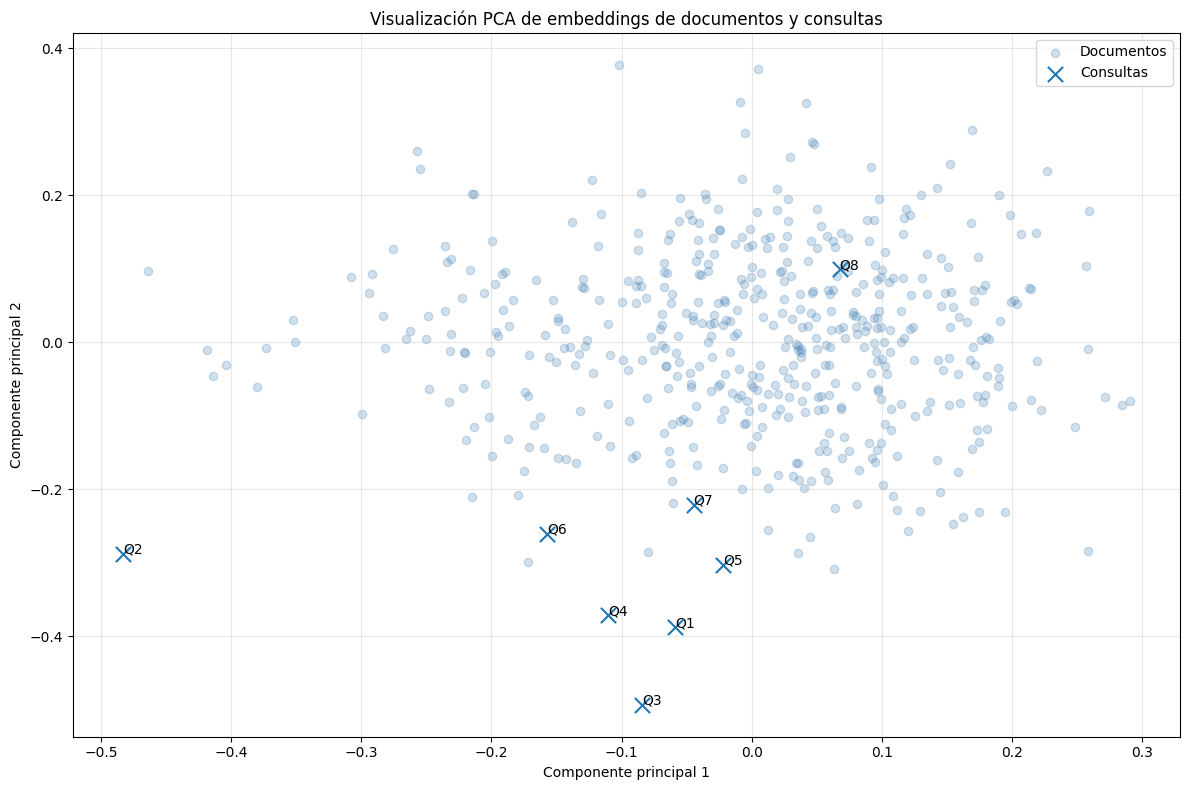

In [63]:
# Tomamos una muestra de documentos para visualizar.
N_VIS = min(500, len(corpus_df))
sample_indices = np.random.RandomState(42).choice(len(corpus_df), size=N_VIS, replace=False)

sample_embeddings = doc_embeddings[sample_indices]
sample_titles = corpus_df.loc[sample_indices, title_col].astype(str).tolist() if title_col is not None else ["Documento"] * N_VIS

query_texts = list(queries.values())
query_embeddings = model.encode(
    [preprocess_text(q) for q in query_texts],
    convert_to_numpy=True,
    normalize_embeddings=True
)

combined_embeddings = np.vstack([sample_embeddings, query_embeddings])

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(combined_embeddings)

doc_coords = coords[:N_VIS]
query_coords = coords[N_VIS:]

plt.figure(figsize=(12, 8))
plt.scatter(doc_coords[:, 0], doc_coords[:, 1], alpha=0.25,c="steelblue", label="Documentos")

plt.scatter(query_coords[:, 0], query_coords[:, 1], marker="x", s=120, label="Consultas")

for i, qid in enumerate(queries.keys()):
    plt.annotate(qid, (query_coords[i, 0], query_coords[i, 1]))

plt.title("Visualización PCA de embeddings de documentos y consultas")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Exportar resultados a CSV

Esta celda guarda:
- resultados Top-k por consulta,
- tabla resumen general.


In [64]:
os.makedirs("resultados", exist_ok=True)

for qid, result_df in all_results.items():
    result_df.to_csv(f"resultados/{qid}_topk.csv", index=False, encoding="utf-8-sig")

summary_df.to_csv("resultados/resumen_general.csv", index=False, encoding="utf-8-sig")

print("Resultados exportados en la carpeta resultados/")

Resultados exportados en la carpeta resultados/


## 14. Conclusión

El sistema implementado permite recuperar documentos del corpus Rotten Tomatoes usando embeddings semánticos y similitud coseno.  
Las consultas obligatorias fueron ejecutadas y se presentaron tablas Top-k junto con una tabla resumen general.  
Además, se añadió una mejora de excelencia mediante visualización PCA de embeddings.
